In [ ]:
  # Cargamos el CSV y filtramos inmediatamente para optimizar memoria

  import pandas as pd
  import numpy as np

  # URL del dataset fuente
  URL = "https://www.datos.gov.co/resource/ji8i-4anb.csv"

In [ ]:

    # Seleccionamos únicamente los departamentos de la región Caribe
  cols_trabajo = ['ano', 'departamento', 'desercion', 'repitencia', 'cobertura_bruta', 'tasa_matriculacion_5_16']
  df = pd.read_csv(URL, usecols=cols_trabajo)

In [ ]:
  # Seleccionamos únicamente los departamentos de la región Caribe
  caribe_depts = ['Atlántico', 'Bolívar', 'Cesar', 'Córdoba', 'La Guajira', 'Magdalena', 'Sucre']
  df = df[df['departamento'].isin(caribe_depts)].copy()

In [ ]:
  # Aseguramos que el año sea numérico, manejando errores como NaN
  df['ano'] = pd.to_numeric(df['ano'], errors='coerce')

In [ ]:
  # Normalizamos separadores decimales y convertimos a float
  cols_num = ['desercion', 'repitencia', 'cobertura_bruta', 'tasa_matriculacion_5_16']
  for col in cols_num:
      if df[col].dtype == 'object':
          df[col] = df[col].str.replace(',', '.')
      df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
  # Análisis de nulos antes del tratamiento
  resumen_antes = df.isnull().mean() * 100

  for col in cols_num:
      pct_nulos = df[col].isnull().mean() * 100
      if pct_nulos < 5:
          # Eliminamos filas si la pérdida de datos es mínima (< 5%)
          df = df.dropna(subset=[col])
      elif pct_nulos >= 5:
          # Imputamos con la mediana por departamento para preservar la varianza regional
          df[col] = df.groupby('departamento')[col].transform(lambda x: x.fillna(x.median()))
# Análisis de nulos después del tratamiento
  resumen_despues = df.isnull().mean() * 100
  print("Resumen Nulos Antes (%):\n", resumen_antes)
  print("\nResumen Nulos Después (%):\n", resumen_despues)

Resumen Nulos Antes (%):
 ano                        0.0
departamento               0.0
tasa_matriculacion_5_16    0.0
cobertura_bruta            0.0
desercion                  0.0
repitencia                 0.0
dtype: float64

Resumen Nulos Después (%):
 ano                        0.0
departamento               0.0
tasa_matriculacion_5_16    0.0
cobertura_bruta            0.0
desercion                  0.0
repitencia                 0.0
dtype: float64


In [ ]:
  # Eliminamos registros idénticos y reportamos la cantidad
  filas_antes = len(df)
  df = df.drop_duplicates()
  print(f"\nFilas eliminadas por duplicados: {filas_antes - len(df)}")


Filas eliminadas por duplicados: 0


In [ ]:
import pandas as pd

# Ensure df_limpio is available. If not, load it.
if 'df_limpio' not in locals() and 'df_limpio' not in globals():
    try:
        # Corrected filename with space
        df_limpio = pd.read_csv('caribe_educacion_limpio .csv')
        print("df_limpio loaded from 'caribe_educacion_limpio .csv'")
    except FileNotFoundError:
        print("Error: 'caribe_educacion_limpio .csv' not found. Please run the data preprocessing cells first.")
        raise # Re-raise the error to stop execution if the file isn't there

# Define the renaming mapping based on current df_limpio columns
mapping = {
    'anio': 'AÑO',
    'desercion': 'Desercion',
    'repitencia': 'Repitencia',
    'cobertura_bruta': 'cobertura bruta',
    'tasa_matriculacion': 'matriculacion' # Adjusted key to match current df_limpio column
}

# Aplicamos el renombramiento de columnas a df_limpio
df_limpio = df_limpio.rename(columns=mapping)
print("Columnas actualizadas:", df_limpio.columns.tolist())

Columnas actualizadas: ['AÑO', 'departamento', 'matriculacion', 'cobertura bruta', 'Desercion', 'Repitencia', 'nivel_desercion']


In [ ]:
  # Clasificamos la deserción en tercios basándonos en los cuantiles del dataset
  df['nivel_desercion'] = pd.qcut(
      df['desercion'],
      q=[0, 0.33, 0.66, 1.0],
      labels=['bajo', 'medio', 'alto']
  )

In [ ]:
  # Guardamos el resultado final y verificamos estructura y tipos
  df_limpio = df
  df_limpio.to_csv('caribe_educacion_limpio.csv', index=False)

  print("\nVerificación Final:")
  print(f"Shape: {df_limpio.shape}")
  print(f"Dtypes:\n{df_limpio.dtypes}")


Verificación Final:
Shape: (98, 7)
Dtypes:
anio                     int64
departamento            object
tasa_matriculacion     float64
cobertura_bruta        float64
desercion              float64
repitencia             float64
nivel_desercion       category
dtype: object


df_limpio loaded from 'caribe_educacion_limpio .csv'


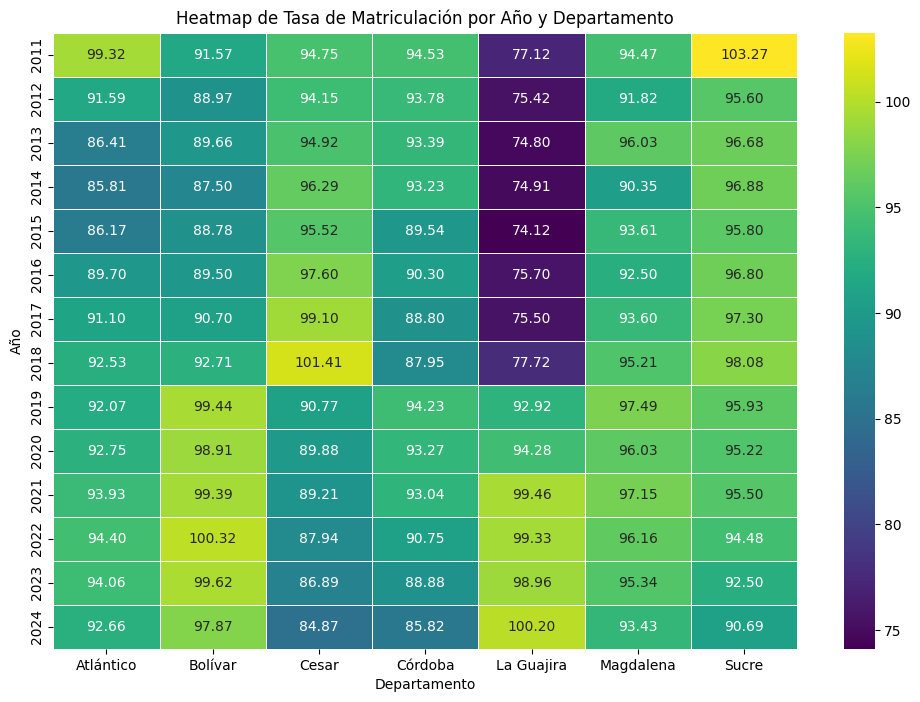

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df_limpio is available. If not, load it.
if 'df_limpio' not in locals() and 'df_limpio' not in globals():
    try:
        # Corrected filename with space
        df_limpio = pd.read_csv('caribe_educacion_limpio .csv')
        print("df_limpio loaded from 'caribe_educacion_limpio .csv'")
    except FileNotFoundError:
        print("Error: 'caribe_educacion_limpio .csv' not found. Please run the data preprocessing cells first.")
        raise # Re-raise the error to stop execution if the file isn't there

# Calculate the average 'tasa_matriculacion' per year and department
heatmap_data = df_limpio.groupby(['anio', 'departamento'])['tasa_matriculacion'].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Tasa de Matriculación por Año y Departamento')
plt.xlabel('Departamento')
plt.ylabel('Año')
plt.show()

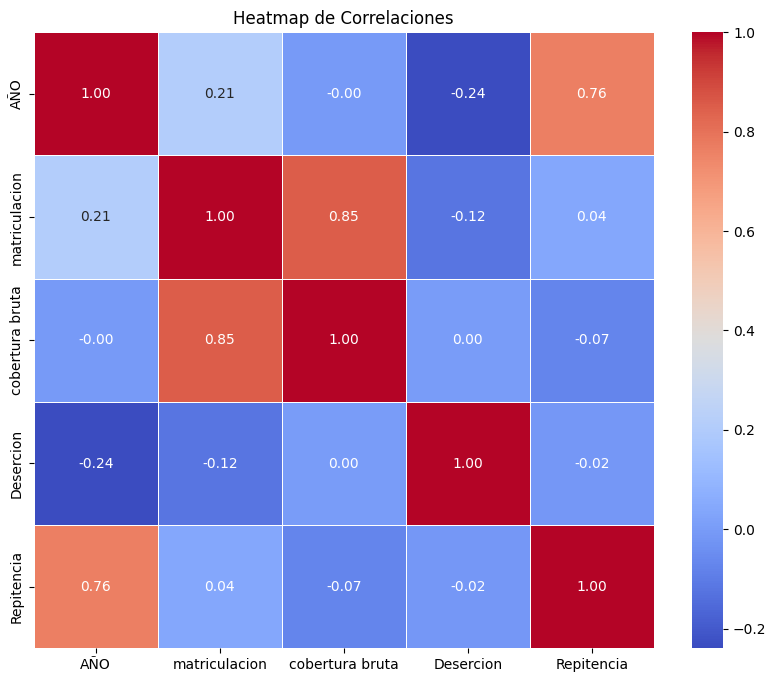

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df_limpio is available. If not, load it.
if 'df_limpio' not in locals() and 'df_limpio' not in globals():
    try:
        # Corrected filename with space
        df_limpio = pd.read_csv('caribe_educacion_limpio .csv')
        print("df_limpio loaded from 'caribe_educacion_limpio .csv'")
    except FileNotFoundError:
        print("Error: 'caribe_educacion_limpio .csv' not found. Please run the data preprocessing cells first.")
        raise # Re-raise the error to stop execution if the file isn't there

# Calculate the correlation matrix for numerical columns
correlation_matrix = df_limpio.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlaciones')
plt.show()

/tmp/ipykernel_58983/2615814908.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_matriculacion_by_dept.index, y=avg_matriculacion_by_dept.values, palette='viridis')


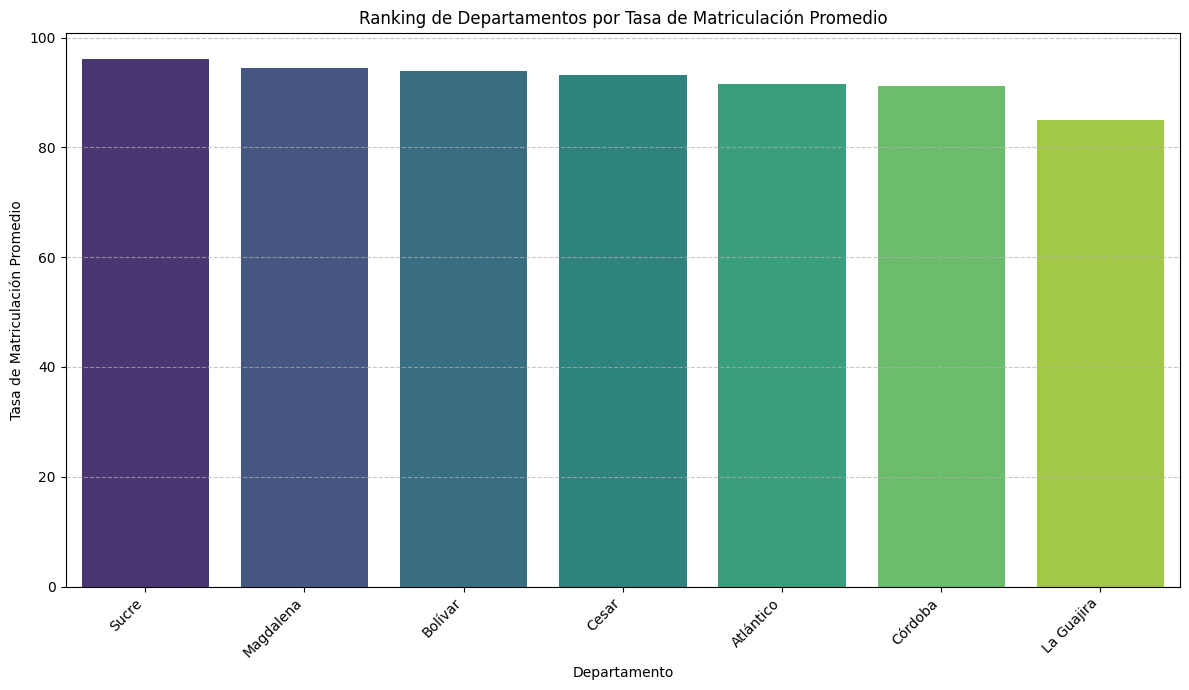

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df_limpio is available. If not, load it.
if 'df_limpio' not in locals() and 'df_limpio' not in globals():
    try:
        # Corrected filename with space (assuming current filename is 'caribe_educacion_limpio .csv')
        df_limpio = pd.read_csv('caribe_educacion_limpio .csv')
        print("df_limpio loaded from 'caribe_educacion_limpio .csv'")
    except FileNotFoundError:
        print("Error: 'caribe_educacion_limpio .csv' not found. Please run the data preprocessing cells first.")
        raise # Re-raise the error to stop execution if the file isn't there

# Calculate the average 'matriculacion' per department
avg_matriculacion_by_dept = df_limpio.groupby('departamento')['matriculacion'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7)) # Adjust figure size for vertical bars
sns.barplot(x=avg_matriculacion_by_dept.index, y=avg_matriculacion_by_dept.values, palette='viridis')
plt.title('Ranking de Departamentos por Tasa de Matriculación Promedio')
plt.xlabel('Departamento')
plt.ylabel('Tasa de Matriculación Promedio')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

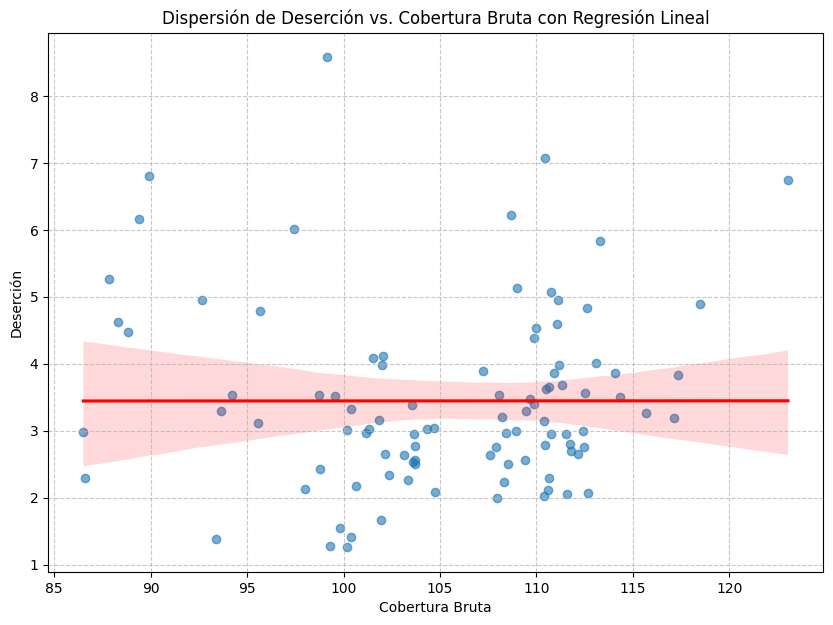

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df_limpio is available. If not, load it.
# This block is for robustness, but df_limpio is expected to be in memory.
if 'df_limpio' not in locals() and 'df_limpio' not in globals():
    try:
        # Corrected filename with space
        df_limpio = pd.read_csv('caribe_educacion_limpio .csv')
        print("df_limpio loaded from 'caribe_educacion_limpio .csv'")
    except FileNotFoundError:
        print("Error: 'caribe_educacion_limpio .csv' not found. Please run the data preprocessing cells first.")
        raise # Re-raise the error to stop execution if the file isn't there

plt.figure(figsize=(10, 7))
sns.regplot(x='cobertura bruta', y='Desercion', data=df_limpio, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Dispersión de Deserción vs. Cobertura Bruta con Regresión Lineal')
plt.xlabel('Cobertura Bruta')
plt.ylabel('Deserción')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()